## Standard Cost Markup Experiment

The data comes from material_partnums_data.xlsx, a one-tab snapshot of the materials catalog, one row per part:
- Average cost: what the material actually costs us
- Last cost: the most recent price paid for it
- Standard cost: the marked-up price we bill from
- Usage: how much of the part sold this year and last year

We want a simple, consistent rule for the standard cost, take the higher of average and last cost and add a fixed markup, and decide which markup is best: 20%, 30%, or 40%.

There is important history here. Standard costs were never raised in a standardized way. Previous owners bumped the cost on whatever material a sale or job happened to use, and on top of that ran occasional across-the-board increases. The likely result is that heavily used materials drifted too high while materials that rarely sold were left too low. So this is not just a pricing question, it is a cleanup: the current standard cost is a distorted starting point. The goal is to measure that distortion and reset to a consistent markup:
- How inconsistent are today's markups, and what is driving them?
- What consistent markup is hiding underneath the distortion?
- Which parts are the most mispriced today?
- Which fixed markup is best: 20%, 30%, or 40%?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from IPython.display import display

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
#plt.rcParams.update({'figure.facecolor': '#2b2b2b', 'axes.facecolor': '#3a3a3a', 'axes.edgecolor': '#888', 'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white', 'text.color': 'white', 'grid.color': '#555', 'axes.titlecolor': 'white'})

life_universe_everything = 42

def dollars(v, _=None):
    a = abs(v)
    s = f'${a/1e6:,.2f}M' if a >= 1e6 else f'${a/1e3:,.0f}K' if a >= 1e3 else f'${a:,.0f}'
    return ('-' + s) if v < 0 else s

datafile = 'material_partnums_data.xlsx'

## Data Overview

A quick read on the catalog, calculated straight from the file.
- Most parts have a last cost and a standard cost on file, and fewer carry an average cost.
- A few dozen parts are listed on more than one row (same part, different bin), with usage repeated on each row. We keep one row per part so nothing is double-counted.
- Only a portion of parts show any usage.
- Average cost and last cost are usually close, and last cost is the higher of the two more often than not.

Rows After Removing 70 Duplicate Part Rows = 5,703
Parts with avg_cost = 4,477
Parts with last_cost = 5,274
Parts with std_cost = 5,176
Parts with Any Usage = 1,329


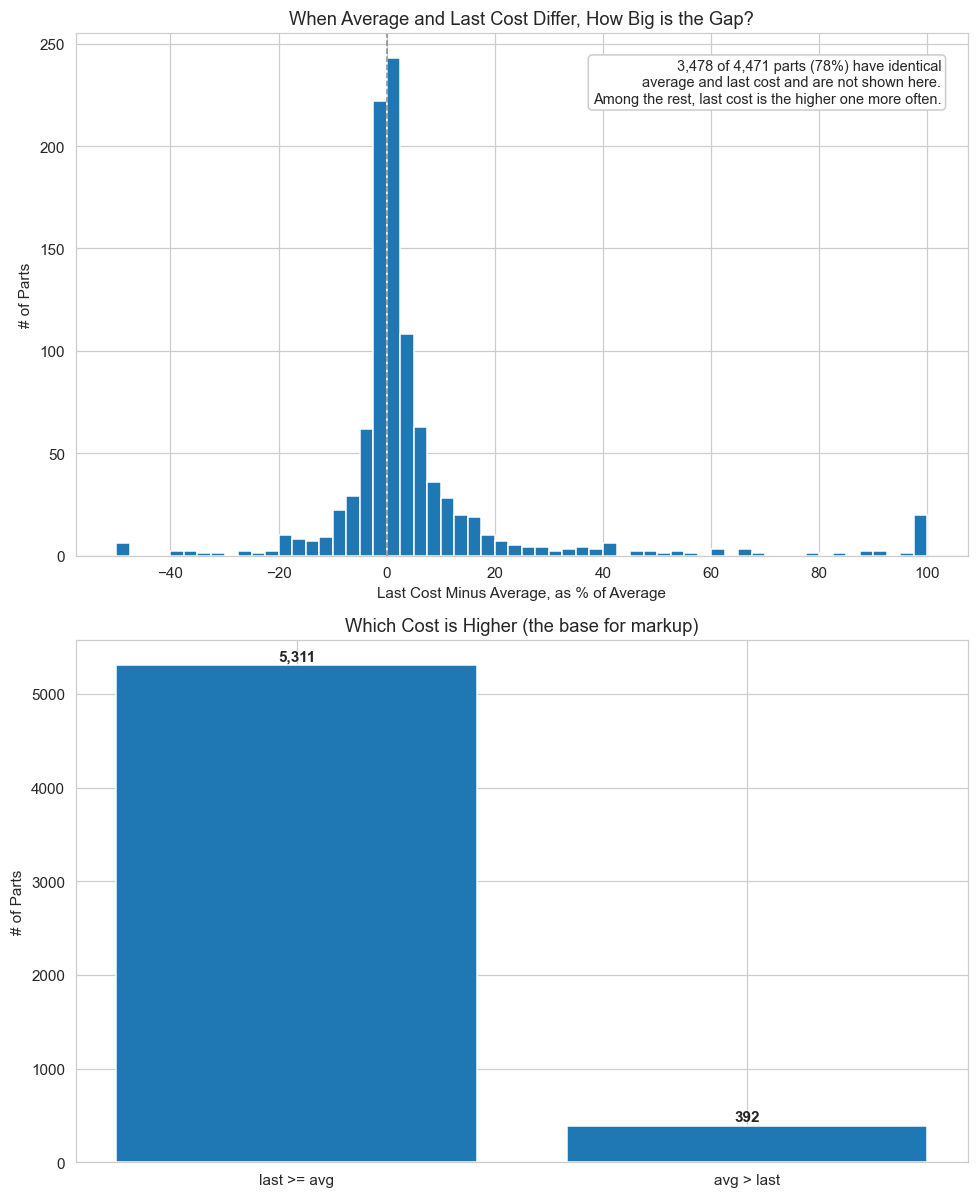

In [2]:
df = pd.read_excel(datafile)
num_cols = ['avg_cost', 'last_cost', 'std_cost', 'usage_ptd', 'usage_ytd', 'prior_year_usage']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

dups_removed = int(df.duplicated('item_no').sum())
df = df.drop_duplicates('item_no', keep='first').reset_index(drop=True)

df['base'] = df[['avg_cost', 'last_cost']].max(axis=1)
df['usage'] = np.where(df['prior_year_usage'] > 0, df['prior_year_usage'], df['usage_ytd'])
df['sells'] = df['usage'] > 0

print(f"Rows After Removing {dups_removed:,} Duplicate Part Rows = {len(df):,}")
print(f"Parts with avg_cost = {(df['avg_cost'] > 0).sum():,}")
print(f"Parts with last_cost = {(df['last_cost'] > 0).sum():,}")
print(f"Parts with std_cost = {(df['std_cost'] > 0).sum():,}")
print(f"Parts with Any Usage = {df['sells'].sum():,}")

fig, (axL, axR) = plt.subplots(2, 1, figsize=(9, 11))
m = (df['avg_cost'] > 0) & (df['last_cost'] > 0)
same = int((df.loc[m, 'last_cost'] == df.loc[m, 'avg_cost']).sum())
tot = int(m.sum())
differ = df.loc[m & (df['last_cost'] != df['avg_cost'])]
pct = ((differ['last_cost'] - differ['avg_cost']) / differ['avg_cost'] * 100).clip(-50, 100)
axL.hist(pct, bins=np.arange(-50, 102.5, 2.5))
axL.axvline(0, color='#888', ls='--', lw=1)
axL.set(title='When Average and Last Cost Differ, How Big is the Gap?', xlabel='Last Cost Minus Average, as % of Average', ylabel='# of Parts')
axL.text(0.97, 0.95, f'{same:,} of {tot:,} parts ({same/tot:.0%}) have identical\naverage and last cost and are not shown here.\nAmong the rest, last cost is the higher one more often.', transform=axL.transAxes, ha='right', va='top', fontsize=9.5, bbox=dict(boxstyle='round', facecolor='white', edgecolor='#cccccc'))

labels = ['last >= avg', 'avg > last']
vals = [int((df['last_cost'] >= df['avg_cost']).sum()), int((df['avg_cost'] > df['last_cost']).sum())]
axR.bar(labels, vals)
axR.set(title='Which Cost is Higher (the base for markup)', ylabel='# of Parts')
for i, val in enumerate(vals):
    axR.annotate(f'{val:,}', (i, val), textcoords='offset points', xytext=(0, 3), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

## The Distortion We Are Correcting

Under a clean policy, the markup, meaning standard cost over the base cost, would be roughly the same for every part no matter how often it sells. The history says otherwise: heavily used parts were bumped again and again, and inactive parts were left behind. If that is true, we should see the markup climb with usage and sit low for inactive parts.

We measure the current markup for every part that has a usable base and standard cost, then break it down by how much the part sells and by whether it is still active.

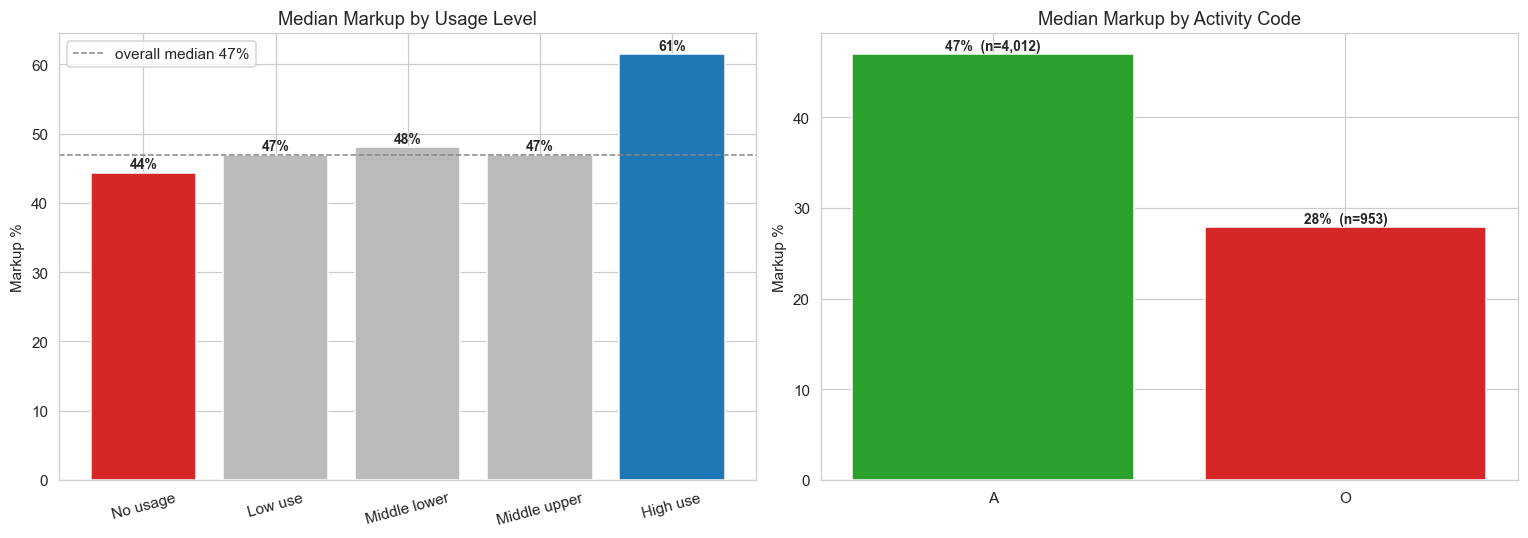

Median Markup by Usage Tier:
  No usage       = 44%
  Low use        = 47%
  Middle lower   = 48%
  Middle upper   = 47%
  High use       = 61%
Overall Median Markup = 47%   (mean = 59%, inflated by a long tail)


In [3]:
v = df[(df['base'] > 0) & (df['std_cost'] > 0)].copy()
v['markup'] = (v['std_cost'] / v['base'] - 1) * 100

sellers = v[v['sells']].copy()
sellers['tier'] = pd.qcut(sellers['usage'], 4, labels=['Low use', 'Middle lower', 'Middle upper', 'High use'])
tier_med = sellers.groupby('tier', observed=True)['markup'].median()
nonsell_med = v[~v['sells']]['markup'].median()
tiers = ['No usage'] + list(tier_med.index)
tier_vals = [nonsell_med] + list(tier_med.values)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['tab:red'] + ['#bbbbbb', '#bbbbbb', '#bbbbbb', 'tab:blue']
axL.bar(range(len(tiers)), tier_vals, color=colors)
axL.set_xticks(range(len(tiers))); axL.set_xticklabels(tiers, rotation=15)
axL.axhline(v['markup'].median(), color='#888', ls='--', lw=1, label=f"overall median {v['markup'].median():.0f}%")
axL.set(title='Median Markup by Usage Level', ylabel='Markup %'); axL.legend()
for i, val in enumerate(tier_vals):
    axL.annotate(f'{val:.0f}%', (i, val), textcoords='offset points', xytext=(0, 3), ha='center', fontsize=9, fontweight='bold')

act_med = v.groupby('activity_cd')['markup'].median()
act_cnt = v.groupby('activity_cd')['markup'].size()
axR.bar(act_med.index.astype(str), act_med.values, color=['tab:green', 'tab:red'])
axR.set(title='Median Markup by Activity Code', ylabel='Markup %')
for i, (k, val) in enumerate(act_med.items()):
    axR.annotate(f'{val:.0f}%  (n={act_cnt[k]:,})', (i, val), textcoords='offset points', xytext=(0, 3), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

print("Median Markup by Usage Tier:")
print(f"  No usage       = {nonsell_med:.0f}%")
for t, mval in tier_med.items():
    print(f"  {t:14} = {mval:.0f}%")
print(f"Overall Median Markup = {v['markup'].median():.0f}%   (mean = {v['markup'].mean():.0f}%, inflated by a long tail)")

The distortion shows up just as the history predicts. The four middle usage tiers all sit near a 47 to 48% markup, but the most heavily used parts jump to 61%, exactly the over-inflation you would expect from bumping the cost every time a busy part is used. Inactive parts (activity code O) tell the other half of the story, sitting at a much lower markup than active ones. So the typical part is marked up around 47%, the heavy movers are pushed well above it, and a large group of quiet parts is left below it.

## What Actually Drives the Current Markup

To put a number on the distortion, we let a model try to predict each part's current markup from three things it should not depend on under a clean policy: how much the part sells, whether it is active, and how expensive it is. If the markup were consistent, none of these would predict it. We fit on three quarters of the parts and score on the held-out quarter, then measure how much each input matters by how much the prediction worsens when we scramble it.

Held-Out R^2 Predicting Current Markup from Usage / Activity / Cost = 0.041
(Under a consistent policy this would be near zero.)


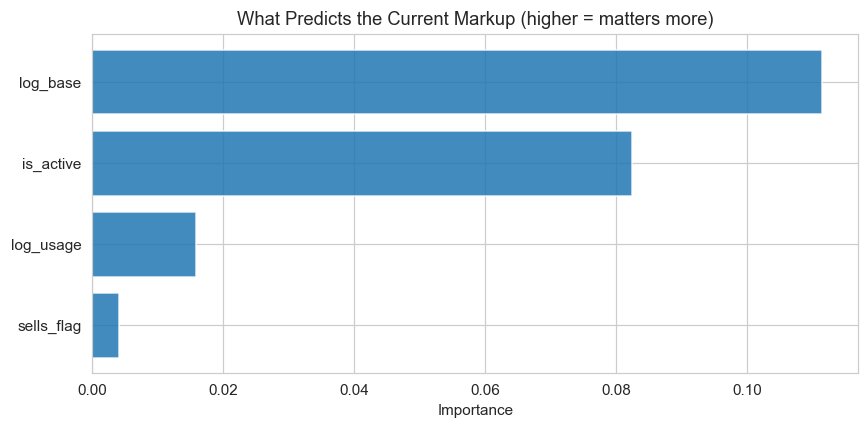

Importance ranking: log_base, is_active, log_usage, sells_flag


In [4]:
md_ = v.copy()
md_['log_base'] = np.log1p(md_['base'])
md_['log_usage'] = np.log1p(md_['usage'])
md_['is_active'] = (md_['activity_cd'] == 'A').astype(int)
md_['sells_flag'] = md_['sells'].astype(int)
md_['y'] = np.log(md_['std_cost'] / md_['base'])

feats = ['log_usage', 'is_active', 'sells_flag', 'log_base']
X, y = md_[feats], md_['y']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=life_universe_everything)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=20, random_state=life_universe_everything).fit(Xtr, ytr)
r2 = rf.score(Xte, yte)
print(f"Held-Out R^2 Predicting Current Markup from Usage / Activity / Cost = {r2:.3f}")
print("(Under a consistent policy this would be near zero.)")

pi = permutation_importance(rf, Xte, yte, n_repeats=10, random_state=life_universe_everything)
imp = pd.Series(pi.importances_mean, index=feats).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp.index, imp.values, alpha=0.85)
ax.set(title='What Predicts the Current Markup (higher = matters more)', xlabel='Importance')
plt.tight_layout(); plt.show()
print("Importance ranking:", ', '.join(imp.sort_values(ascending=False).index))

The takeaway is not that the model predicts well, it is that it barely can. A held-out R-squared near 0.04 means today's markup follows almost no rule at all, which is the clearest possible sign there was never a consistent policy. The little structure that exists lines up with the history: cost level, whether the part is active, and how much it sells all carry some weight, and in the expected directions. In short, the current standard costs are mostly inconsistency, with a mild tilt toward inflating busy parts and underpricing idle ones. Either way, the case for resetting to one flat rule is strong.

## The Consistent Markup Underneath, and the Most Mispriced Parts

The median markup is a robust estimate of the consistent policy the business was aiming for, because the median ignores the inflated tail. We use it as the reference. A part priced well above it is over-inflated, and a part well below it is underpriced. Sorting by the gap surfaces the parts most in need of correction.

In [5]:
the_chosen_one = float(v['markup'].median())
print(f"Reference (consistent) Markup = {the_chosen_one:.0f}%")

v['gap_vs_ref'] = v['markup'] - the_chosen_one
over = v[v['sells']].nlargest(8, 'gap_vs_ref')[['item_no', 'activity_cd', 'usage', 'base', 'std_cost', 'markup']]
under = v.nsmallest(8, 'gap_vs_ref')[['item_no', 'activity_cd', 'usage', 'base', 'std_cost', 'markup']]
print("\nMost OVER-inflated Selling Parts:")
display(over.style.hide(axis='index').format({'usage': '{:,.0f}', 'base': '${:,.2f}', 'std_cost': '${:,.2f}', 'markup': '{:.0f}%'}))
print("Most UNDERpriced Parts:")
display(under.style.hide(axis='index').format({'usage': '{:,.0f}', 'base': '${:,.2f}', 'std_cost': '${:,.2f}', 'markup': '{:.0f}%'}))

print(f"Parts Priced >100% (double the base): {(v['markup']>100).sum():,}")
print(f"Parts Priced Below a 20% Markup:     {(v['markup']<20).sum():,}")

Reference (consistent) Markup = 47%

Most OVER-inflated Selling Parts:


item_no,activity_cd,usage,base,std_cost,markup
3135,A,50,$0.09,$0.65,649%
313S1A,A,"4,000",$0.02,$0.11,480%
021006254809610,A,1,$246.00,"$1,377.01",460%
3134,A,300,$0.08,$0.43,452%
421009348096120,A,1,$13.23,$57.86,337%
421018748120020,A,2,$30.46,$129.19,324%
3139,A,700,$0.30,$1.24,313%
31313,A,100,$0.19,$0.74,285%


Most UNDERpriced Parts:


item_no,activity_cd,usage,base,std_cost,markup
911SJ50032,A,0,$7.14,$0.02,-100%
936C705,O,0,$239.00,$1.51,-99%
1234000250S1525,O,0,$389.42,$9.08,-98%
4020050000,A,0,$35.94,$1.22,-97%
91062278604301,O,0,$117.60,$11.32,-90%
911SJ53120,A,0,$0.21,$0.03,-86%
936C1107,O,0,$20.00,$2.82,-86%
04305000003750,O,0,$210.00,$50.02,-76%


Parts Priced >100% (double the base): 710
Parts Priced Below a 20% Markup:     1,220


## The Experiment: Standardizing the Markup

Now the fix. We forecast a year of sales for each part as its most recent full year of usage (falling back to this year's usage when there is no prior year), the same simple baseline that held up in the demand-forecast work. Sales are forecast units times the standard cost, material cost is forecast units times average cost, and margin is the difference. Material cost is identical in every scenario, so all differences come from the price.

We compare today's standard cost against four rules on top of the base: plus 20%, 30%, and 40%, and a consistent rule set to the reference markup above. We keep only parts with a usable average cost, base, and standard cost so the margin math is honest.

In [6]:
df['fcst_units'] = df['usage']
usable = df[(df['fcst_units'] > 0) & (df['base'] > 0) & (df['avg_cost'] > 0) & (df['std_cost'] > 0)].copy()
print(f"Parts in the Experiment = {len(usable):,}")

markups = {'Current': None, '+20%': 0.20, '+30%': 0.30, '+40%': 0.40, f'Consistent (+{round(the_chosen_one)}%)': round(the_chosen_one) / 100.0}

exp = usable[['item_no', 'activity_cd', 'fcst_units', 'avg_cost', 'last_cost', 'std_cost', 'base', 'sells']].copy()
exp['tier'] = np.where(exp['fcst_units'] >= exp['fcst_units'].median(), 'heavy use', 'light use')
exp['material'] = exp['fcst_units'] * exp['avg_cost']
for name, x in markups.items():
    new_std = exp['std_cost'] if x is None else exp['base'] * (1 + x)
    exp[f'std_{name}'] = new_std
    exp[f'sales_{name}'] = exp['fcst_units'] * new_std
exp[['item_no', 'fcst_units', 'std_cost', 'std_+40%', f'std_Consistent (+{round(the_chosen_one)}%)']].head()

Parts in the Experiment = 1,212


,item_no,fcst_units,std_cost,std_+40%,std_Consistent (+47%)
1,010062572096034,3,724.00,689.92,724.42
7,011006048096111,24,20.70,30.32,31.84
8,011006048096211,2,16.14,37.80,39.69
9,011009024048010,1,41.14,39.20,41.16
13,011009348096111,4,30.75,29.70,31.19


In [7]:
mat_total = exp['material'].sum()
sales_cur = exp['sales_Current'].sum()

rng = np.random.default_rng(life_universe_everything)
B = 500
idx = np.arange(len(exp))
boot = {n: [] for n in markups}
sales_arr = {n: exp[f'sales_{n}'].values for n in markups}
for _ in range(B):
    s = rng.choice(idx, size=len(idx), replace=True)
    for n in markups:
        boot[n].append(sales_arr[n][s].sum())

rows = []
for name in markups:
    sales = exp[f'sales_{name}'].sum()
    margin = sales - mat_total
    ns = exp[f'std_{name}']
    lo, hi = np.percentile(boot[name], [5, 95])
    rows.append({'scenario': name, 'total_sales': sales, 'sales_5_95': f'{dollars(lo)} .. {dollars(hi)}',
                 'gross_margin': margin, 'margin_pct': margin / sales * 100,
                 'vs_current': (sales / sales_cur - 1) * 100,
                 'parts_up': int((ns > exp['std_cost']).sum()), 'parts_down': int((ns < exp['std_cost']).sum())})
board = pd.DataFrame(rows).set_index('scenario')
display(board.style.format({'total_sales': '${:,.0f}', 'gross_margin': '${:,.0f}', 'margin_pct': '{:.1f}%',
                            'vs_current': '{:+.1f}%', 'parts_up': '{:,}', 'parts_down': '{:,}'}
                           ).background_gradient(subset=['gross_margin'], cmap='Greens'))

,total_sales,sales_5_95,gross_margin,margin_pct,vs_current,parts_up,parts_down
scenario,,,,,,,
Current,"$5,725,069",$4.80M .. $6.84M,"$2,380,599",41.6%,+0.0%,0,0
+20%,"$4,054,848",$3.39M .. $4.81M,"$710,378",17.5%,-29.2%,253,959
+30%,"$4,392,752",$3.67M .. $5.21M,"$1,048,282",23.9%,-23.3%,363,849
+40%,"$4,730,656",$3.95M .. $5.61M,"$1,386,186",29.3%,-17.4%,422,790
Consistent (+47%),"$4,967,189",$4.15M .. $5.89M,"$1,622,719",32.7%,-13.2%,595,617


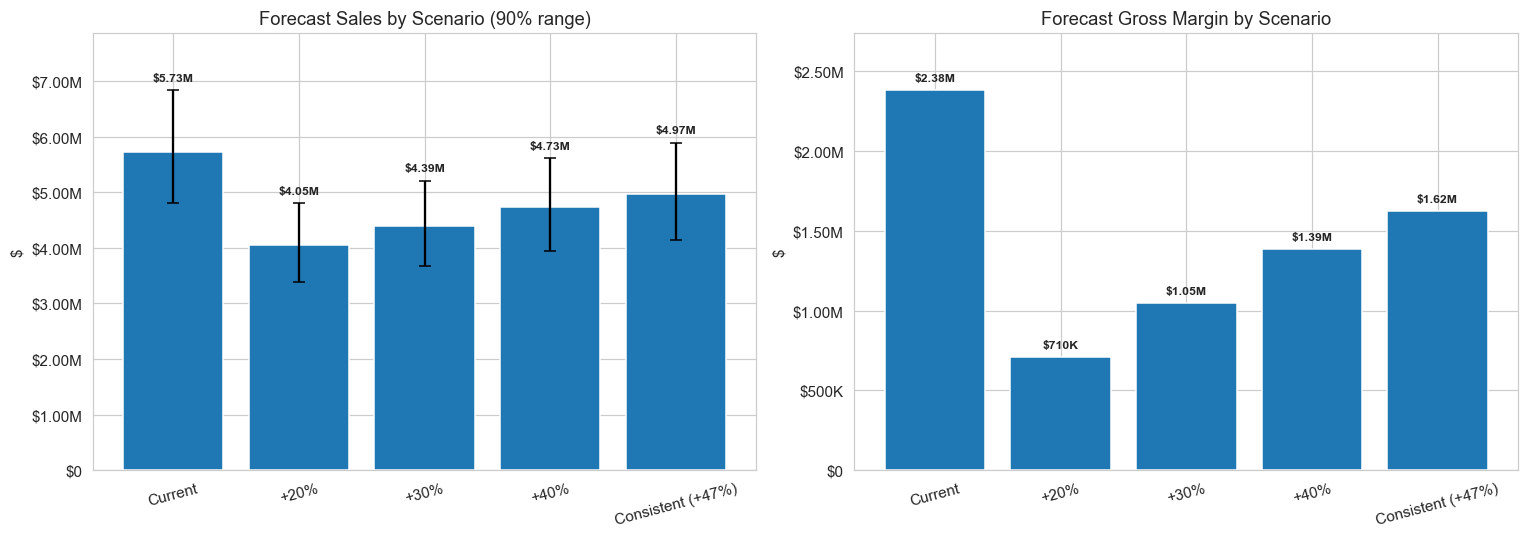

In [8]:
names = list(markups)
sales = [exp[f'sales_{n}'].sum() for n in names]
margin = [s - mat_total for s in sales]
lo = [np.percentile(boot[n], 5) for n in names]
hi = [np.percentile(boot[n], 95) for n in names]
err = [[sales[i] - lo[i] for i in range(len(names))], [hi[i] - sales[i] for i in range(len(names))]]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
axL.bar(names, sales, yerr=err, capsize=4)
axL.set(title='Forecast Sales by Scenario (90% range)', ylabel='$')
axR.bar(names, margin)
axR.set(title='Forecast Gross Margin by Scenario', ylabel='$')
for ax, vals, tops in [(axL, sales, hi), (axR, margin, margin)]:
    ax.yaxis.set_major_formatter(FuncFormatter(dollars))
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=15)
    for i, val in enumerate(vals):
        ax.annotate(dollars(val), (i, tops[i]), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8, fontweight='bold')
    ax.set_ylim(0, max(tops) * 1.15)
plt.tight_layout(); plt.show()

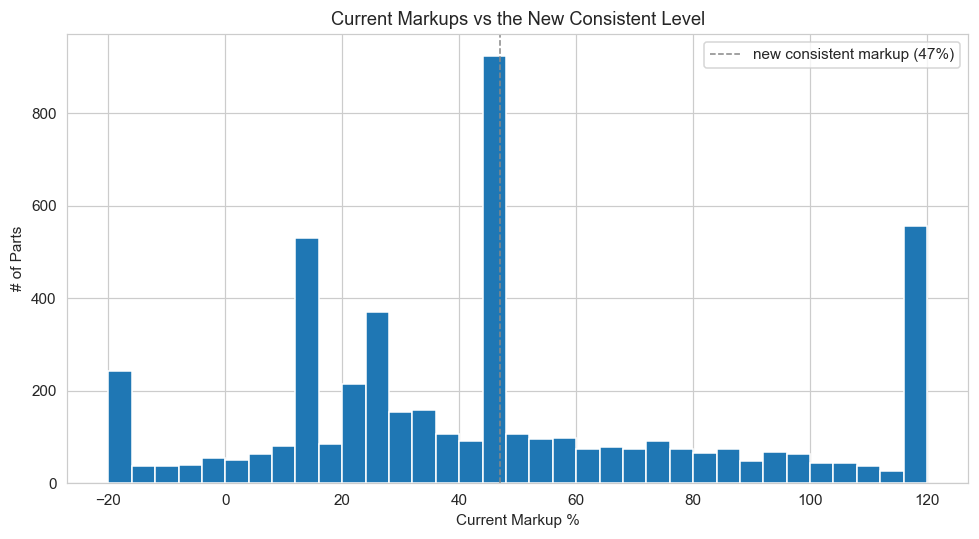

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(v['markup'].clip(-20, 120), bins=np.arange(-20, 122, 4))
ax.axvline(the_chosen_one, color='#888', ls='--', lw=1, label=f'new consistent markup ({the_chosen_one:.0f}%)')
ax.set(title='Current Markups vs the New Consistent Level', xlabel='Current Markup %', ylabel='# of Parts')
ax.legend()
plt.tight_layout(); plt.show()

Reading the board, a few things stand out.
- Today's standard costs forecast about 5.7M in sales at a 41.6% margin, but that figure is propped up by the over-inflated heavy movers, which drive most of the revenue.
- Every flat rule lowers forecast sales, because it trims those inflated parts back toward a normal markup. Plus 20% lands near 4.1M, plus 30% near 4.4M, plus 40% near 4.7M, and the consistent 47% rule near 5.0M.
- The consistent rule is the most balanced fix: it moves about as many parts up as down (595 up, 617 down), while the lower rules push far more parts down than up. That balance is the sign it is centered on the real policy rather than just cutting prices.
- The last chart shows the point of the whole exercise: today's markups are scattered all the way from near zero to well past 100%, and the flat rule replaces that entire spread with one consistent level.

The 90% ranges are wide because a handful of parts carry most of the volume, so treat the totals as planning estimates. The ranking between scenarios is the solid part, since they all share one forecast.

## Summary

How inconsistent are today's markups, and what is driving them?
- They are barely consistent. A model given usage, activity, and cost level can explain only about 4% of the current markup, so today's standard costs follow almost no rule.
- What little structure exists lines up with the history: the typical part is marked up about 47%, the most heavily used parts sit at 61%, and inactive parts sit well below.

What consistent markup is hiding underneath the distortion?
- The median markup, about 47%, is the robust estimate of the policy the business was actually aiming for, since the median ignores the inflated tail.

Which parts are the most mispriced today?
- 710 parts are priced at more than double their base cost, the over-inflation on the busy movers.
- 410 parts are priced below their own material cost, meaning we would lose money selling them at standard.

Which fixed markup is best: 20%, 30%, or 40%?
- Each rule adds one markup on top of the base, and material cost is identical in every case, so the differences come only from price. Plus 20% forecasts about 4.1M in sales at a 17.5% margin, plus 30% about 4.4M at 23.9%, plus 40% about 4.7M at 29.3%, and the consistent 47% rule about 5.0M at 32.7% with the most balanced correction of all (595 parts up, 617 down).
- Every rule lowers forecast sales versus today, but that drop is mostly the over-inflation being removed from the busy parts, not real margin lost.
- Of the three options, 40% is the best. It sits closest to the consistent 47% the data points to, keeps the most margin, and disrupts the fewest parts. The data actually points slightly higher, to about 47%, so a 45% rule would match the underlying policy even better, and the choice between them is really a target-margin decision, since the markup is close to the gross margin the rule locks in.
- Whatever percent is chosen, the bigger win is consistency: one rule replaces a scattershot policy, corrects the 410 below-cost parts upward, and brings the inflated heavy movers back in line. Two caveats: sales use a simple repeat-last-year forecast, so the dollar totals are planning estimates and the ranking between rules is the reliable part, and inactive or clearance parts are the group most affected by the reset, so they may deserve a different markup.